# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FCH4'
RAND_ERR_COL = "FCH4_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.777 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FCH4_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,0.123126,1.196652,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,9.77577,267.16400,0.0,7.366667,...,0.031227,0.385963,0.705085,0.129544,0.000000,0.000000,2.280252,1.041116,29.0,22.0,30.0,22.0,0.086770,0.188254,1039
2023-11-07 16:15:00,1.440639,-0.121658,-4.360399,-4.360399,-4.360399,NaN,NaN,NaN,B,certain,1.0,5.25593,168.35800,0.0,7.300000,...,0.022161,0.321719,0.557017,0.072530,0.000000,0.000000,2.274546,1.037818,29.0,22.0,30.0,22.0,0.086864,0.188641,1040
2023-11-07 17:15:00,2.060704,-0.782134,2.488800,2.488800,2.488800,2.488800,2.488800,2.488800,B,certain,1.0,2.23130,3.38364,0.5,6.600000,...,0.029544,0.798931,0.793294,0.894488,0.000000,0.000000,2.263177,1.031258,29.0,22.0,30.0,22.0,0.087050,0.189415,1042
2023-11-07 17:45:00,1.999698,-0.715234,-9.177059,-9.177059,-9.177059,-9.177059,-9.177059,-9.177059,B,certain,1.0,3.26868,0.00000,0.2,6.633333,...,0.435220,0.764205,0.910265,0.877980,0.000000,0.000000,2.257514,1.027996,29.0,22.0,30.0,22.0,0.087144,0.189803,1043
2023-11-07 18:15:00,1.908674,-0.638819,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.33375,0.00000,0.5,6.366667,...,0.327660,0.897999,1.085670,1.031942,0.000000,0.000000,2.251865,1.024747,29.0,22.0,30.0,22.0,0.087237,0.190191,1044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,5.789159,-1.174224,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,10.56010,0.00000,0.0,15.870000,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.000000,0.000000,14923
2024-08-22 22:15:00,5.719062,-1.229992,49.838100,49.838100,NaN,NaN,NaN,NaN,B,certain,1.0,8.79062,0.00000,0.0,15.160000,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.000000,0.000000,14924
2024-08-22 22:45:00,5.507258,-1.028798,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,10.10600,0.00000,0.0,15.100000,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.000000,0.000000,14925


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')


The treatment variable (trt) is included in the feature set


# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8887995089067299, 'gamma': 0.4692763545078751, 'learning_rate': 0.005077876584101433, 'max_depth': 14, 'min_child_weight': 5, 'n_estimators': 260, 'subsample': 0.7216968971838151}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 8.2670; raw baseline 8.2670)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.105
  Coverage: 174/1473 rows never held out (11.8%); mean times held out 2.03
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_16_QCF0
  RMSE:   12.9274
  MAE:    7.6486
  R2:     0.0531
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 8.6753; raw baseline 8.6753)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.104
  Coverage: 222/1693 rows never held out (13.1%); mean times 

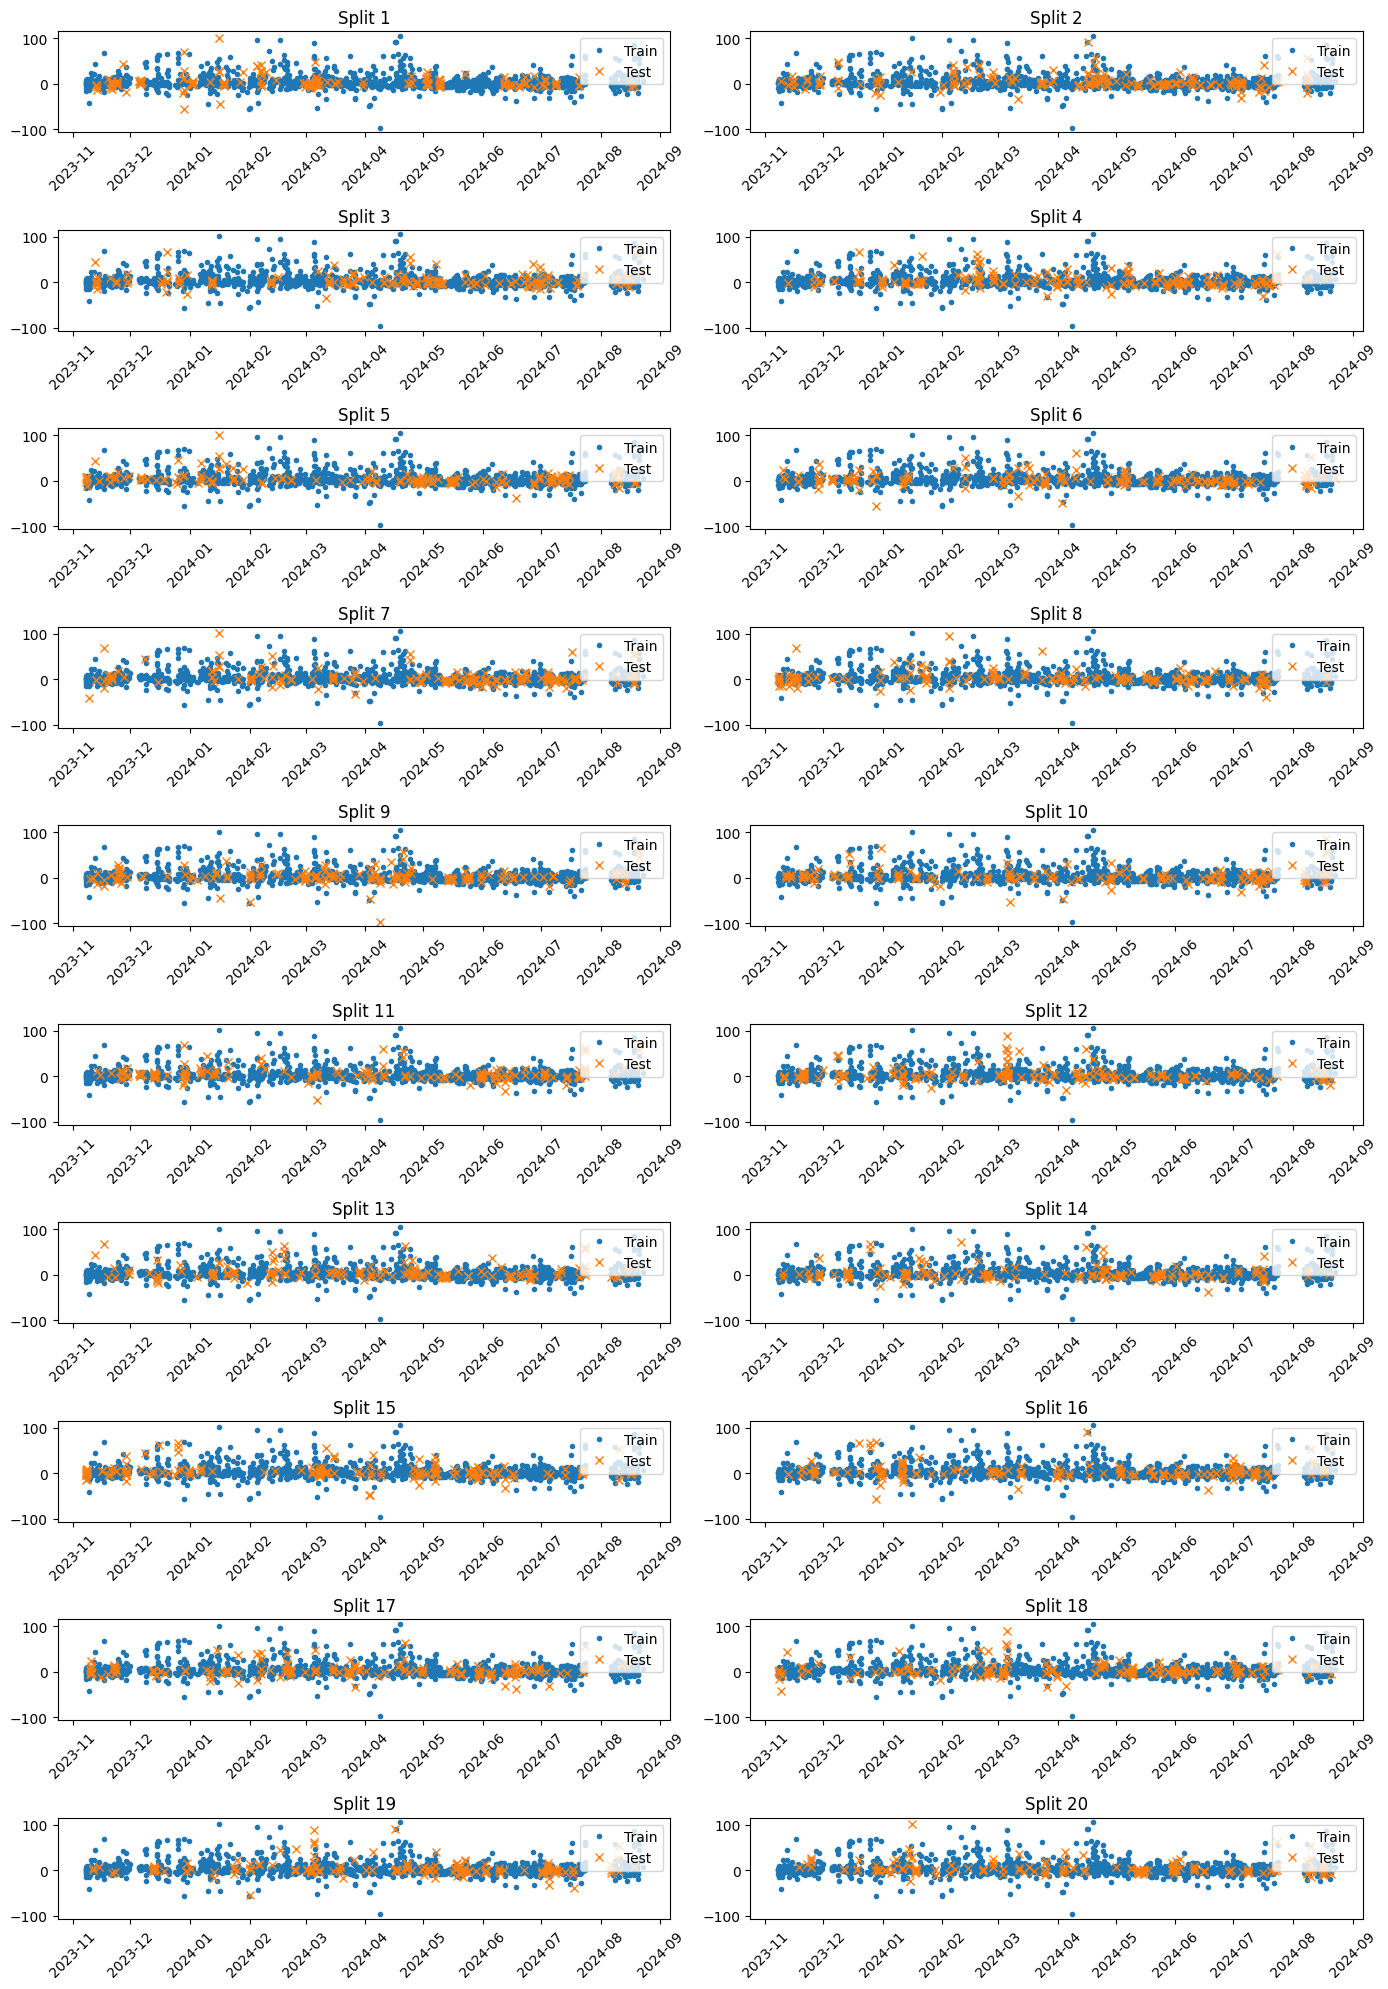

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_16_QCF0
  RMSE:   14.5546
  MAE:    8.9073
  R2:     0.0741
----------------------------------------
Fitting final model on full training set...


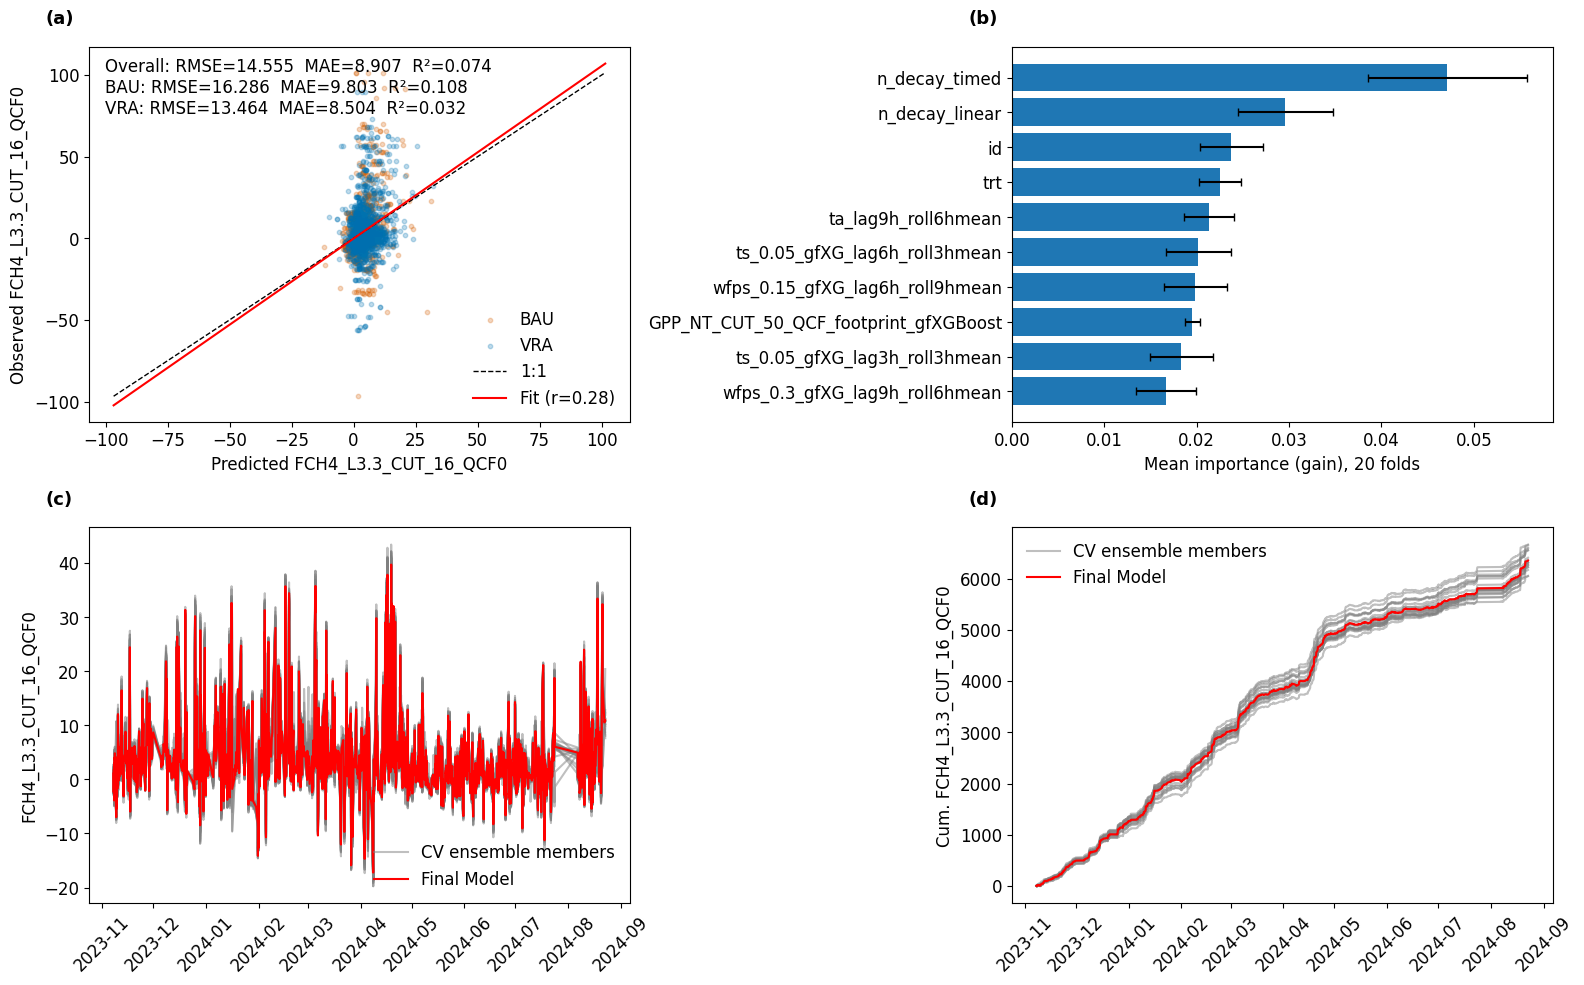

Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

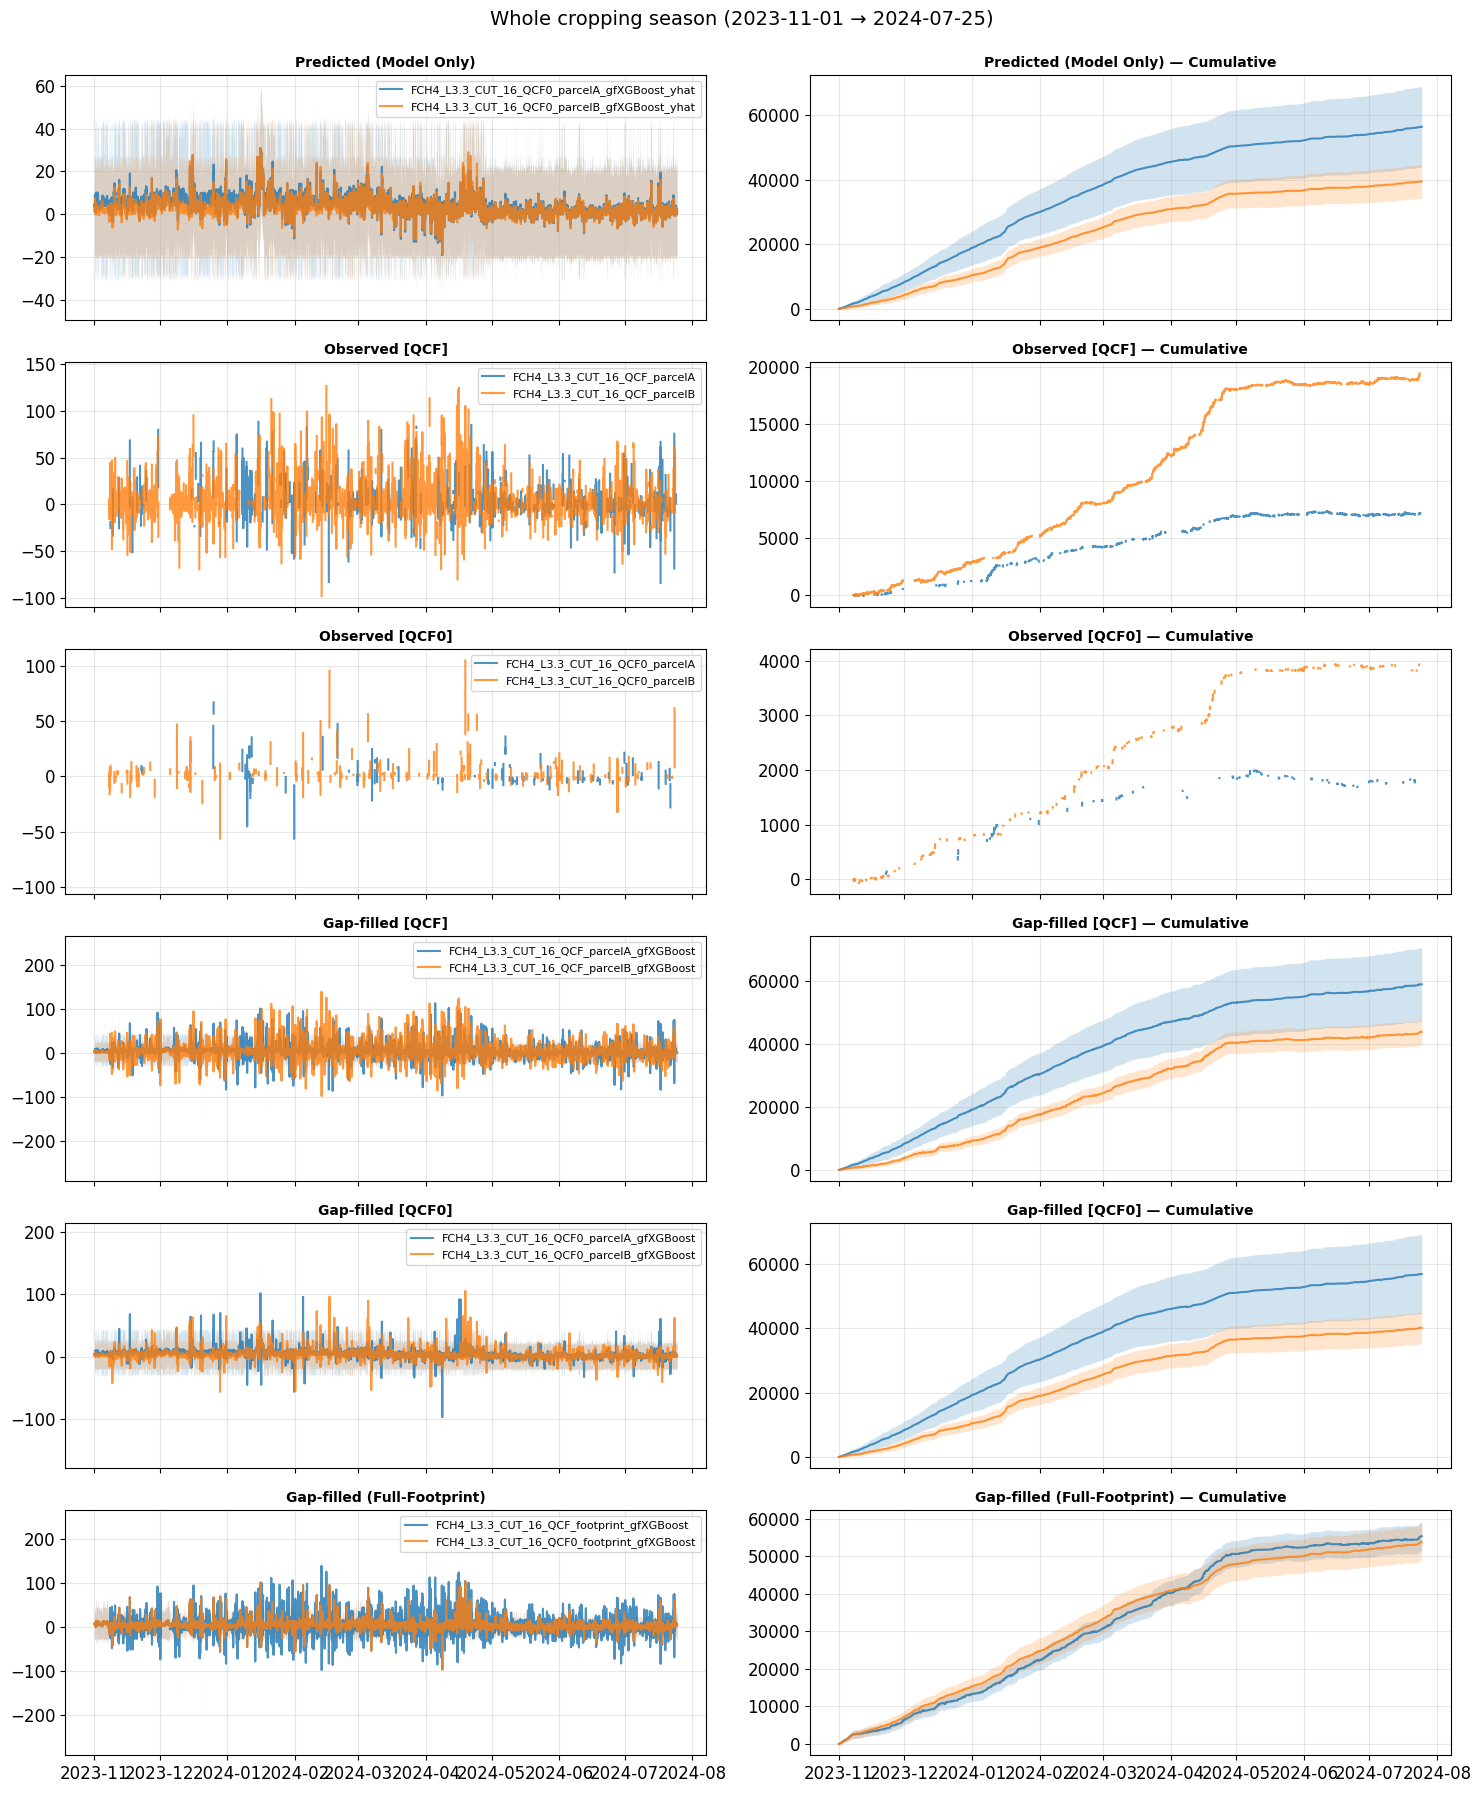

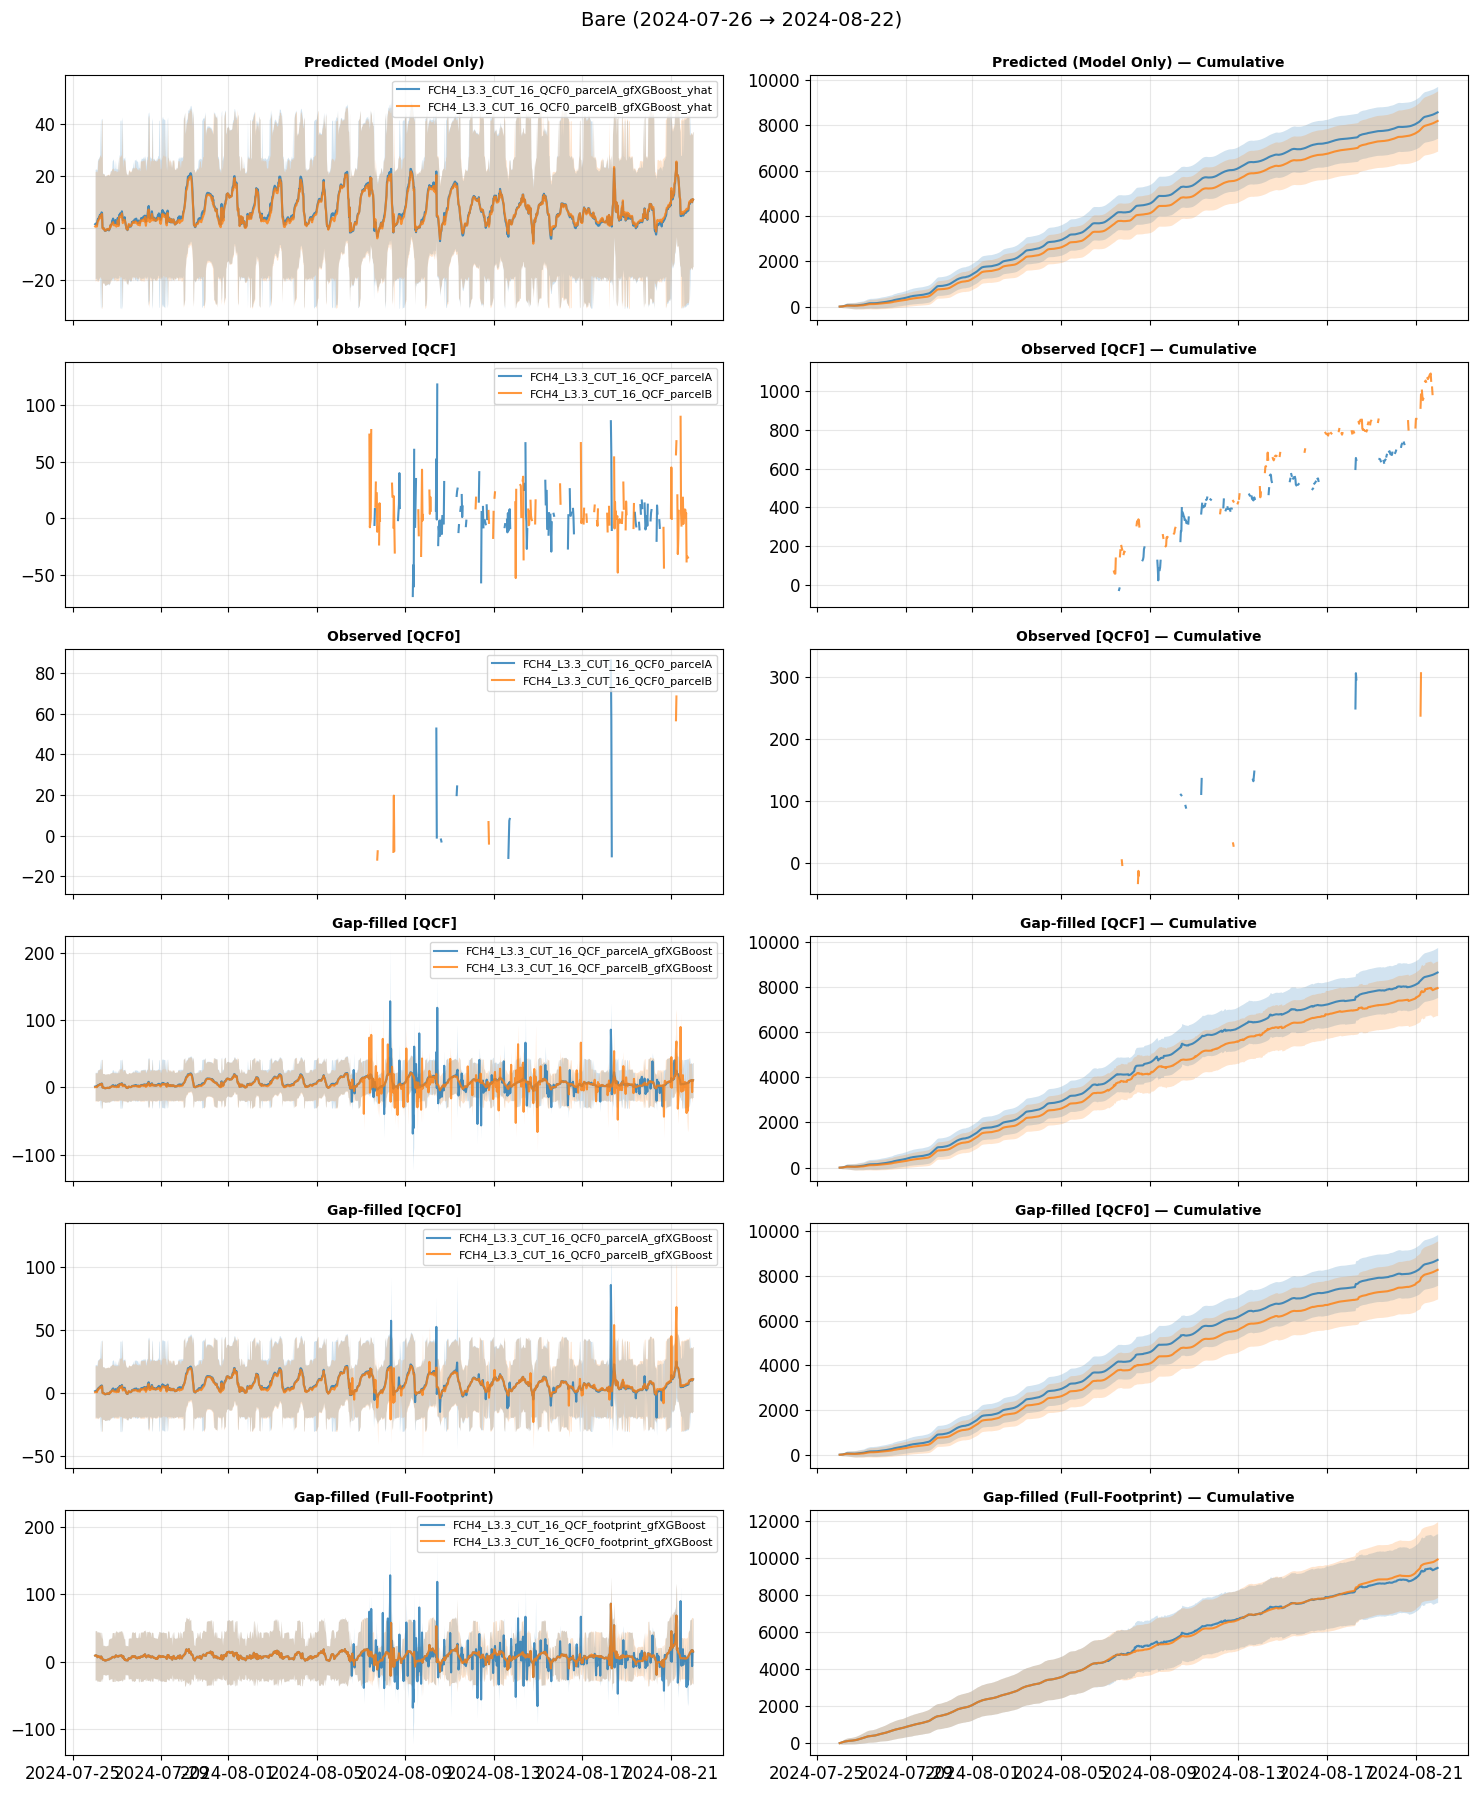

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target=TARGET,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-01", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()

## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 6.3356; raw baseline 6.3356)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.109
  Coverage: 152/1357 rows never held out (11.2%); mean times held out 2.04
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_50_QCF0
  RMSE:   10.8618
  MAE:    6.9117
  R2:     0.0846
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 7.5497; raw baseline 7.5497)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.101-0.103
  Coverage: 162/1552 rows never held out (10.4%); mean times 

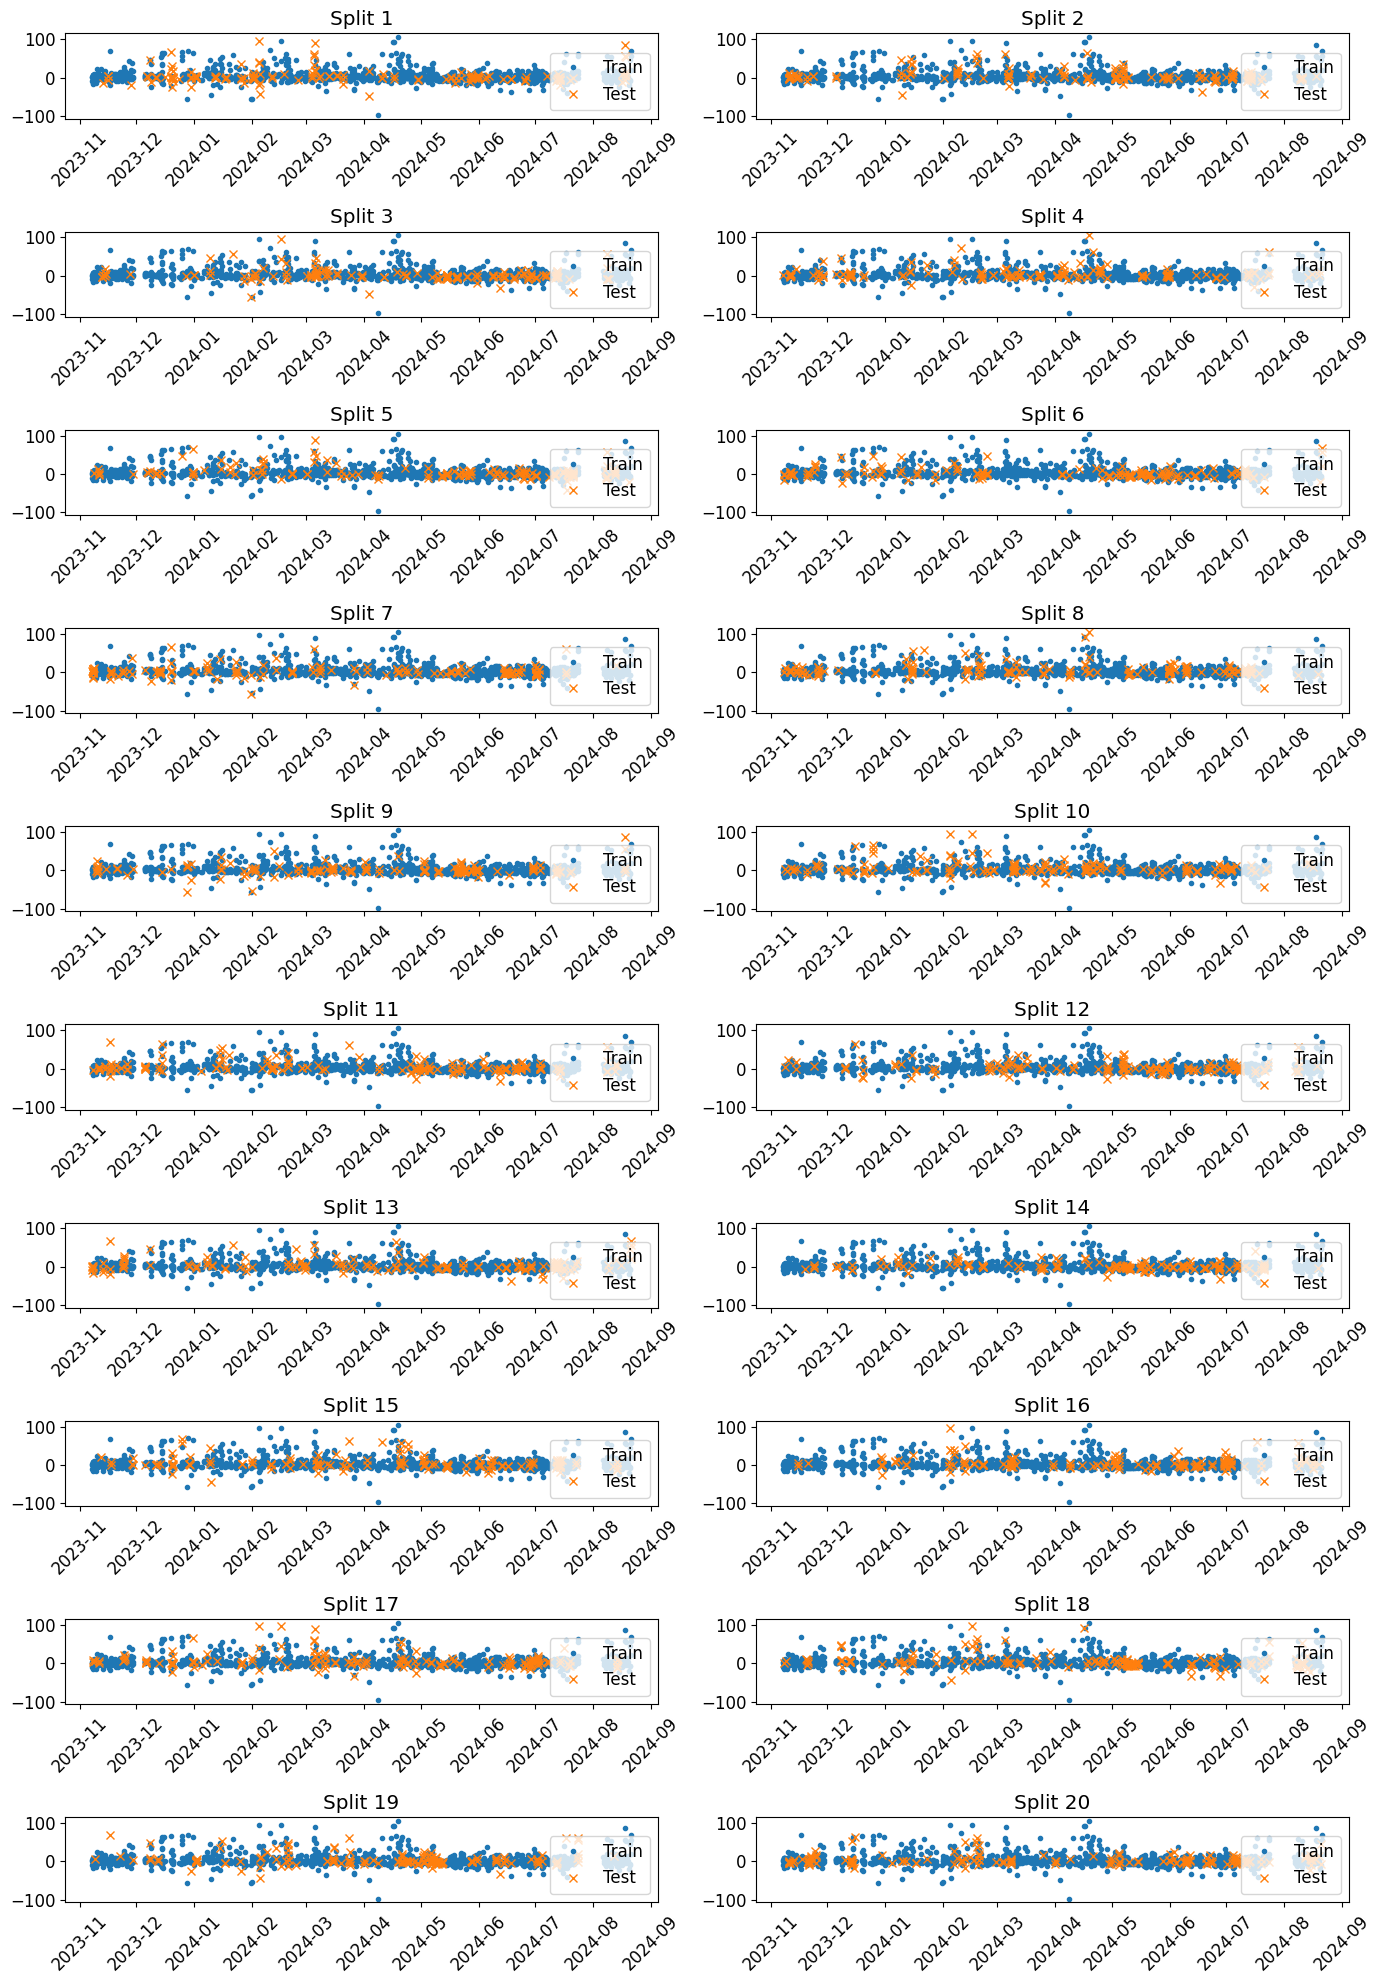

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_50_QCF0
  RMSE:   14.6712
  MAE:    9.0319
  R2:     0.0843
----------------------------------------
Fitting final model on full training set...


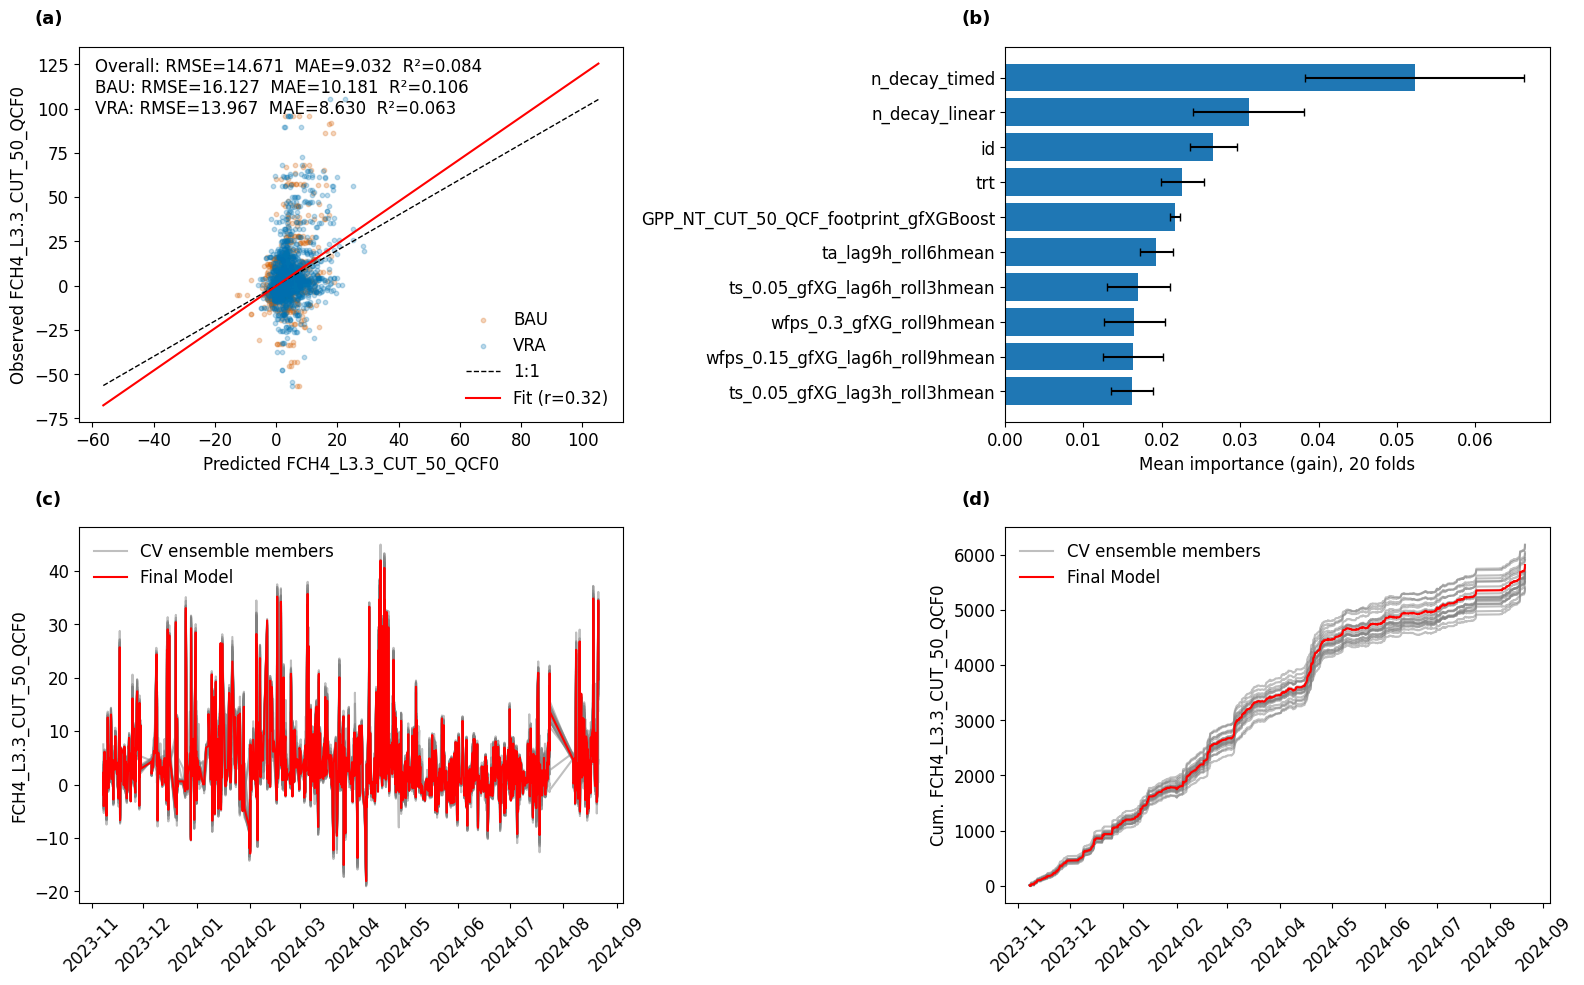

Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

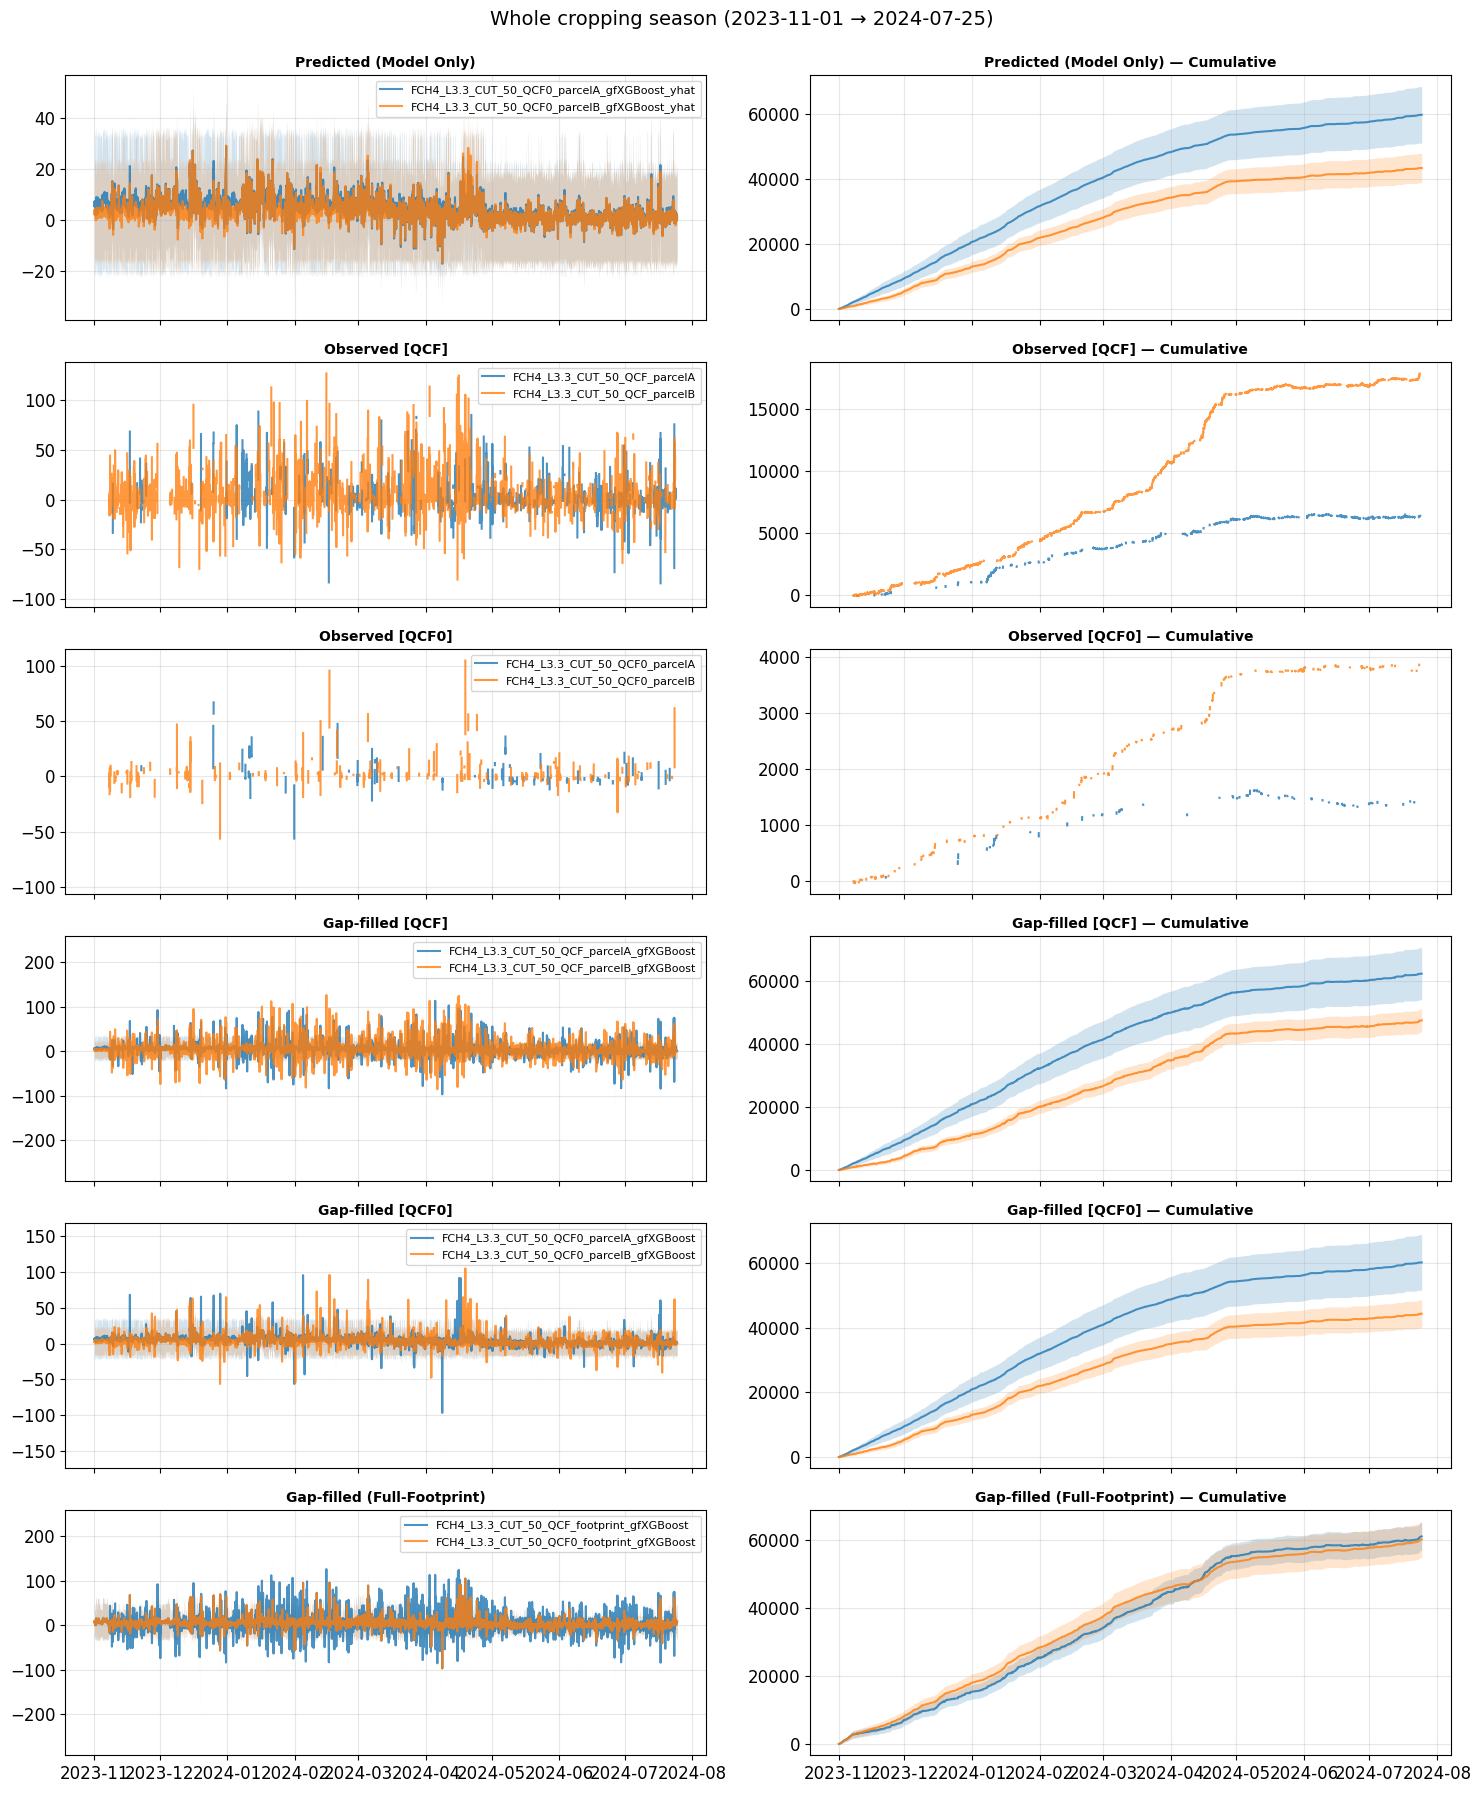

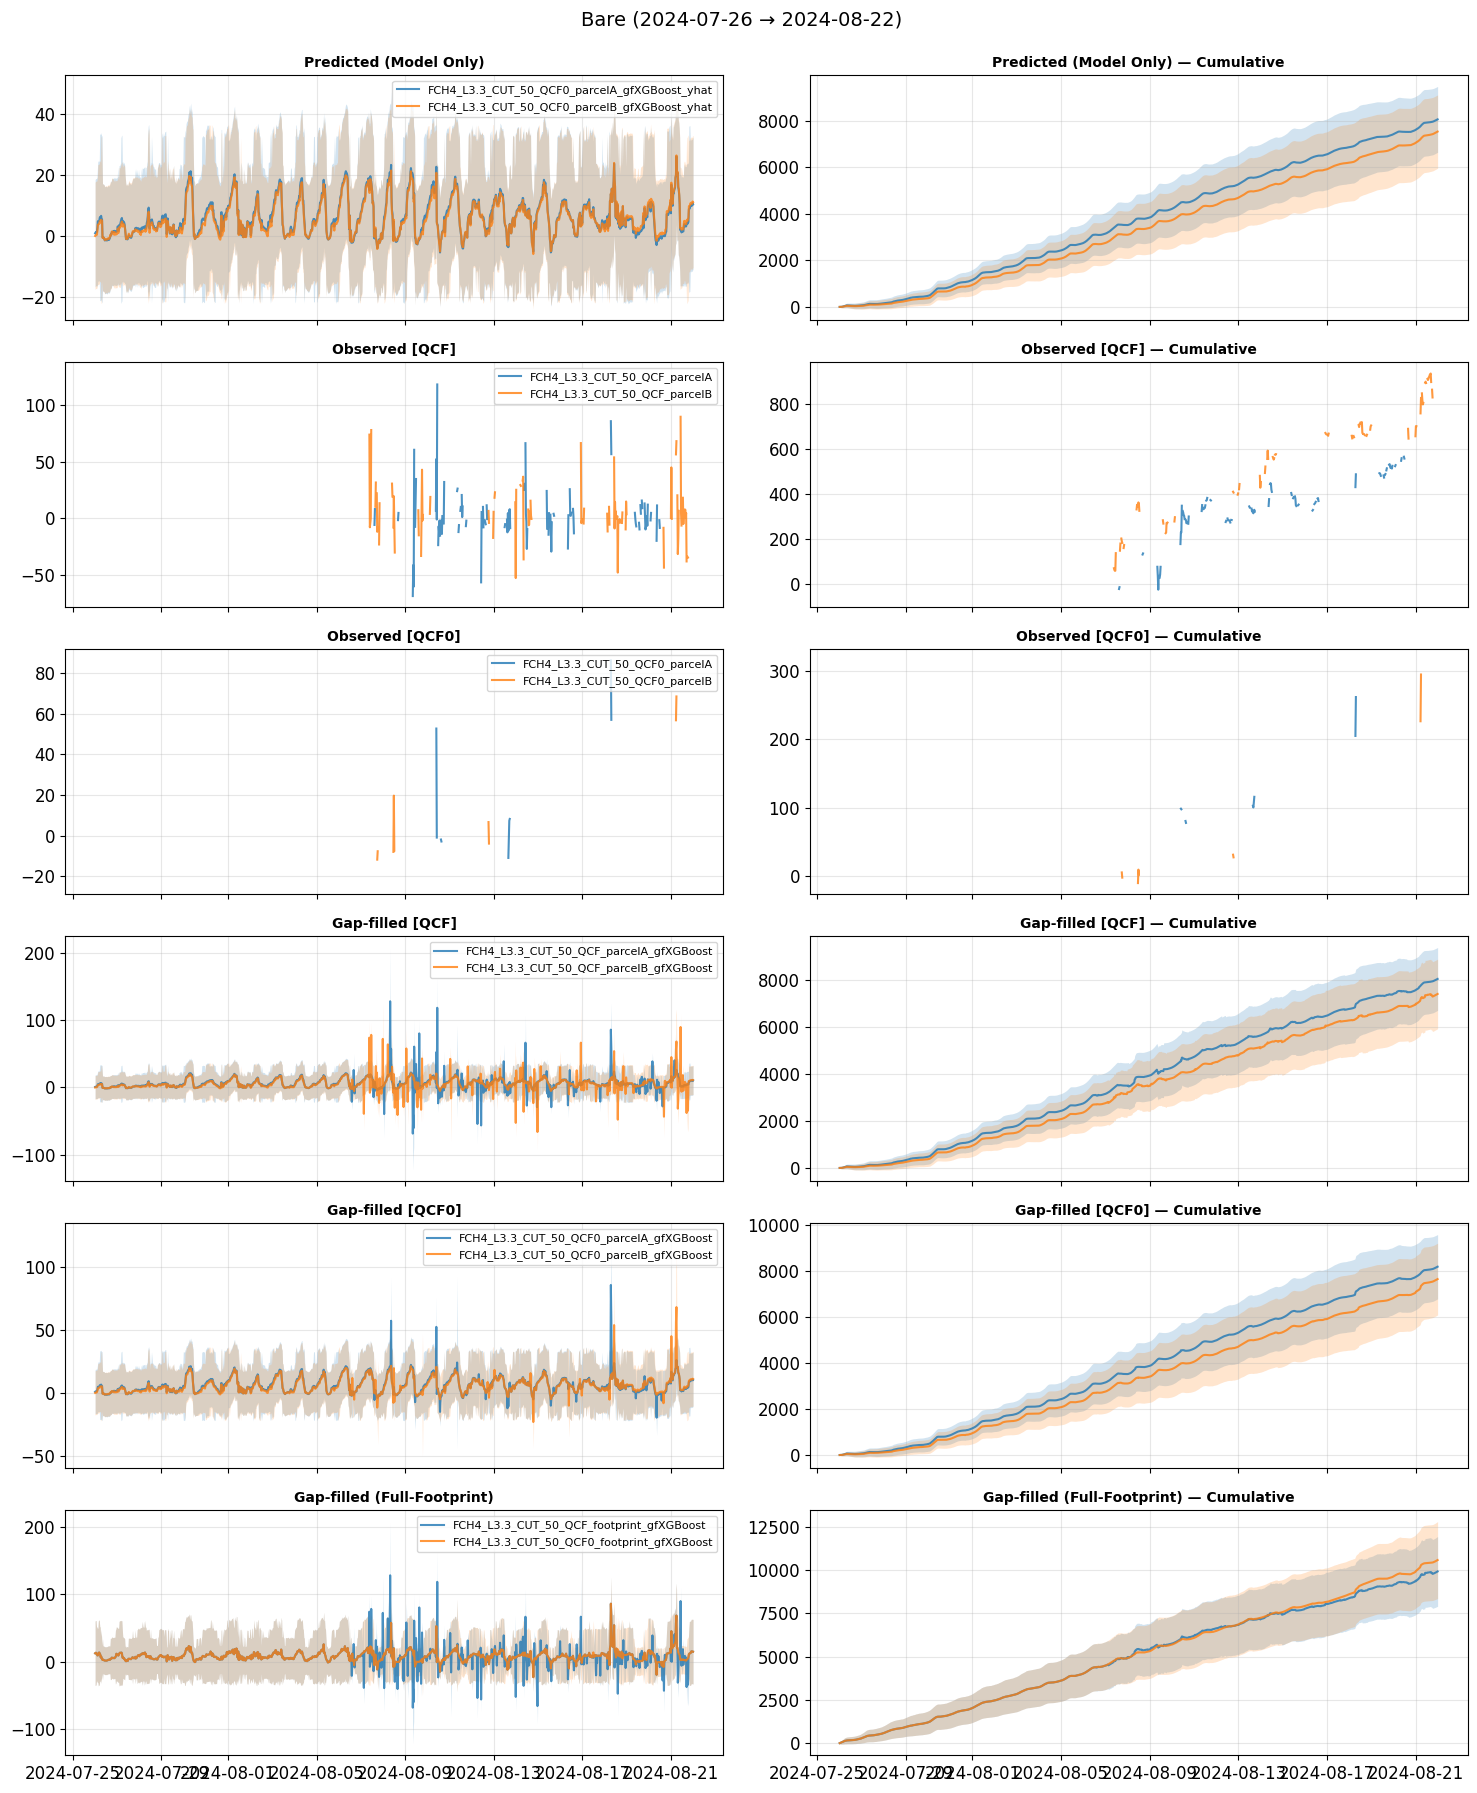

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-01", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()

### SHAP CHECK

100%|===================| 11422/11448 [07:41<00:01]        

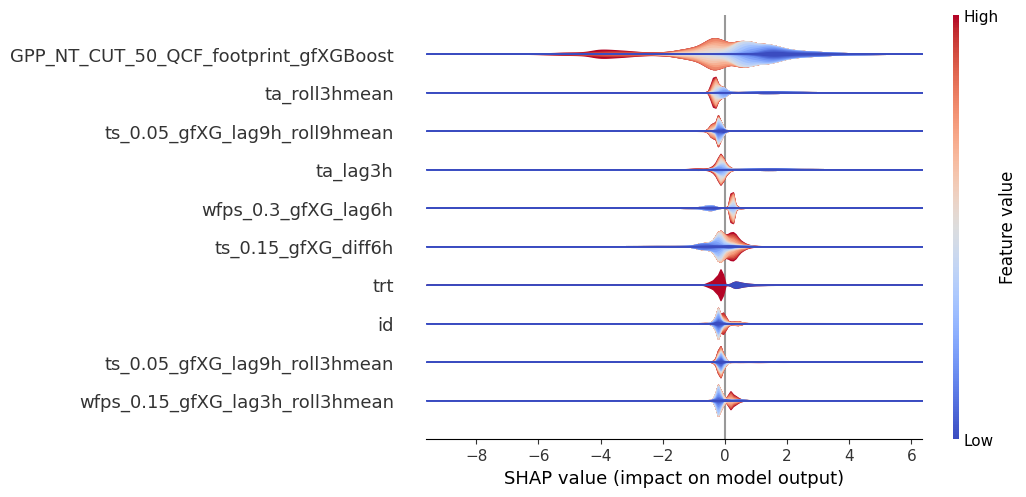

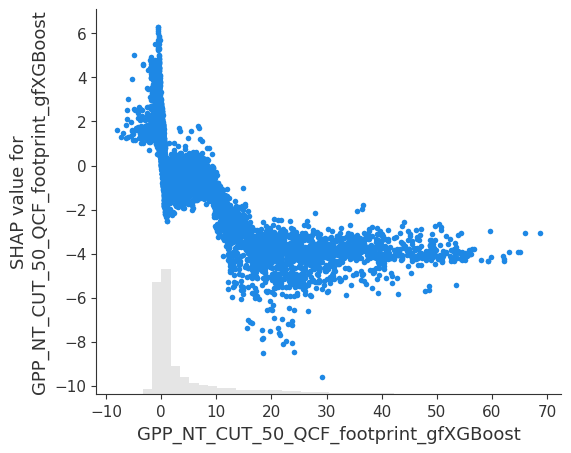

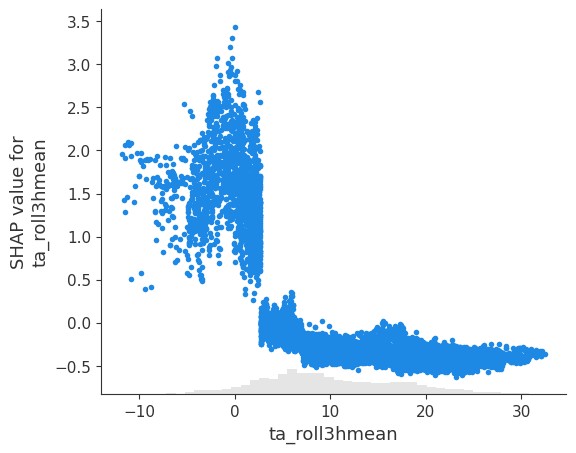

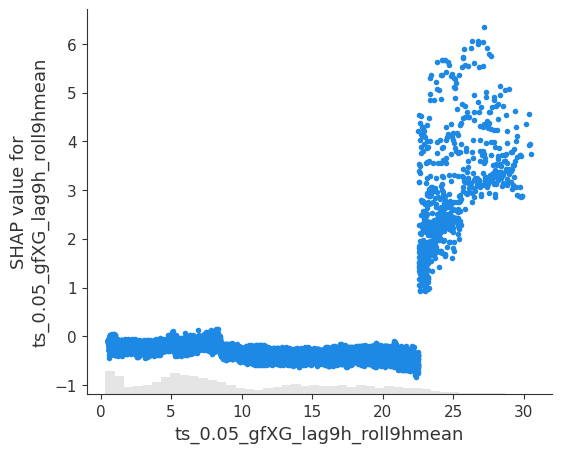

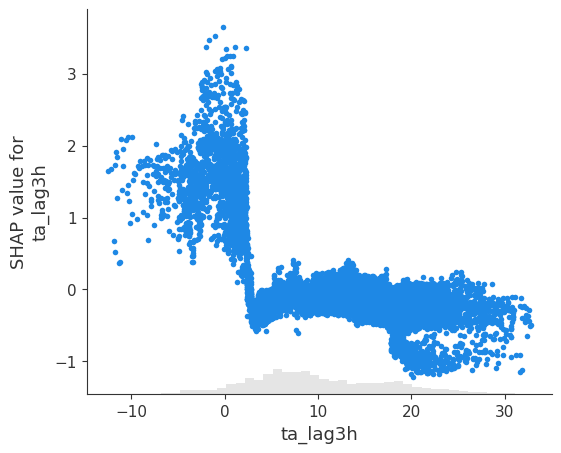

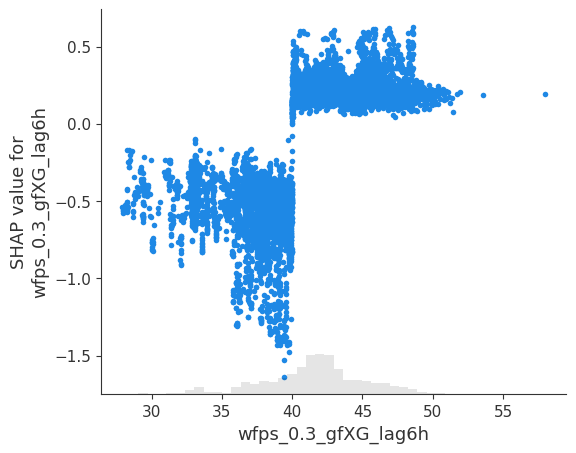

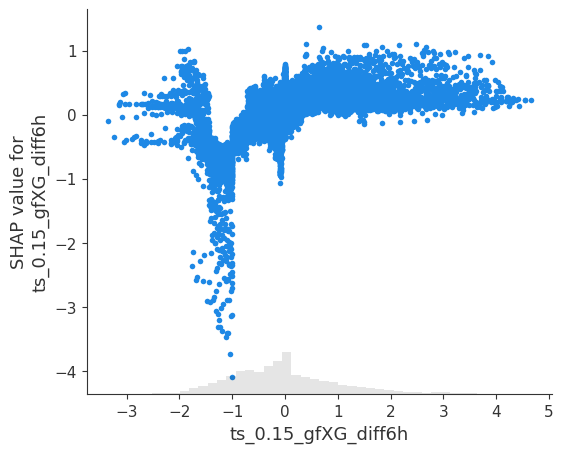

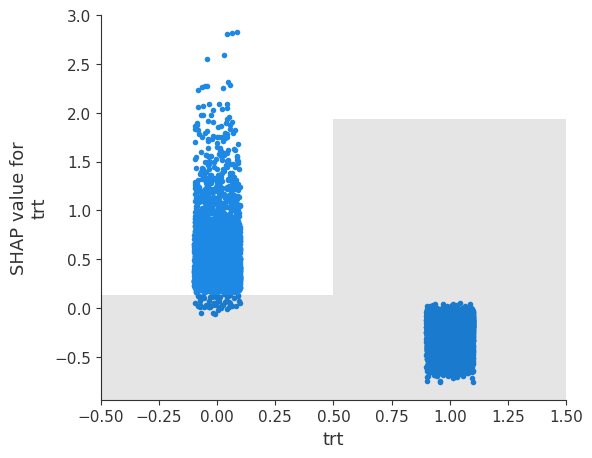

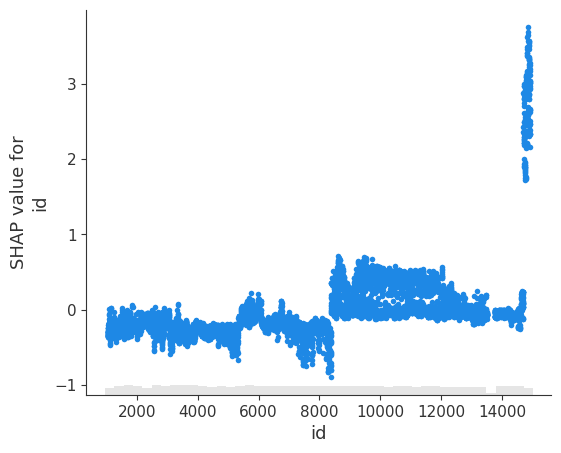

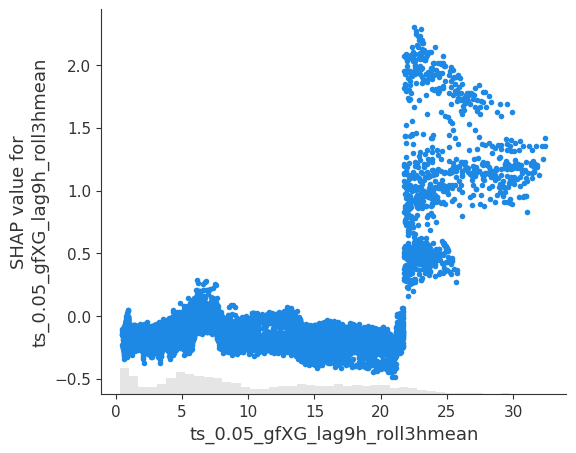

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FCH4_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 5.0783; raw baseline 5.0783)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.108
  Coverage: 151/1220 rows never held out (12.4%); mean times held out 2.02
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_84_QCF0
  RMSE:   10.8622
  MAE:    6.9515
  R2:     0.0237
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: raw empirical (cvm distance 5.8409; raw baseline 5.8409)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.101-0.109
  Coverage: 164/1391 rows never held out (11.8%); mean times 

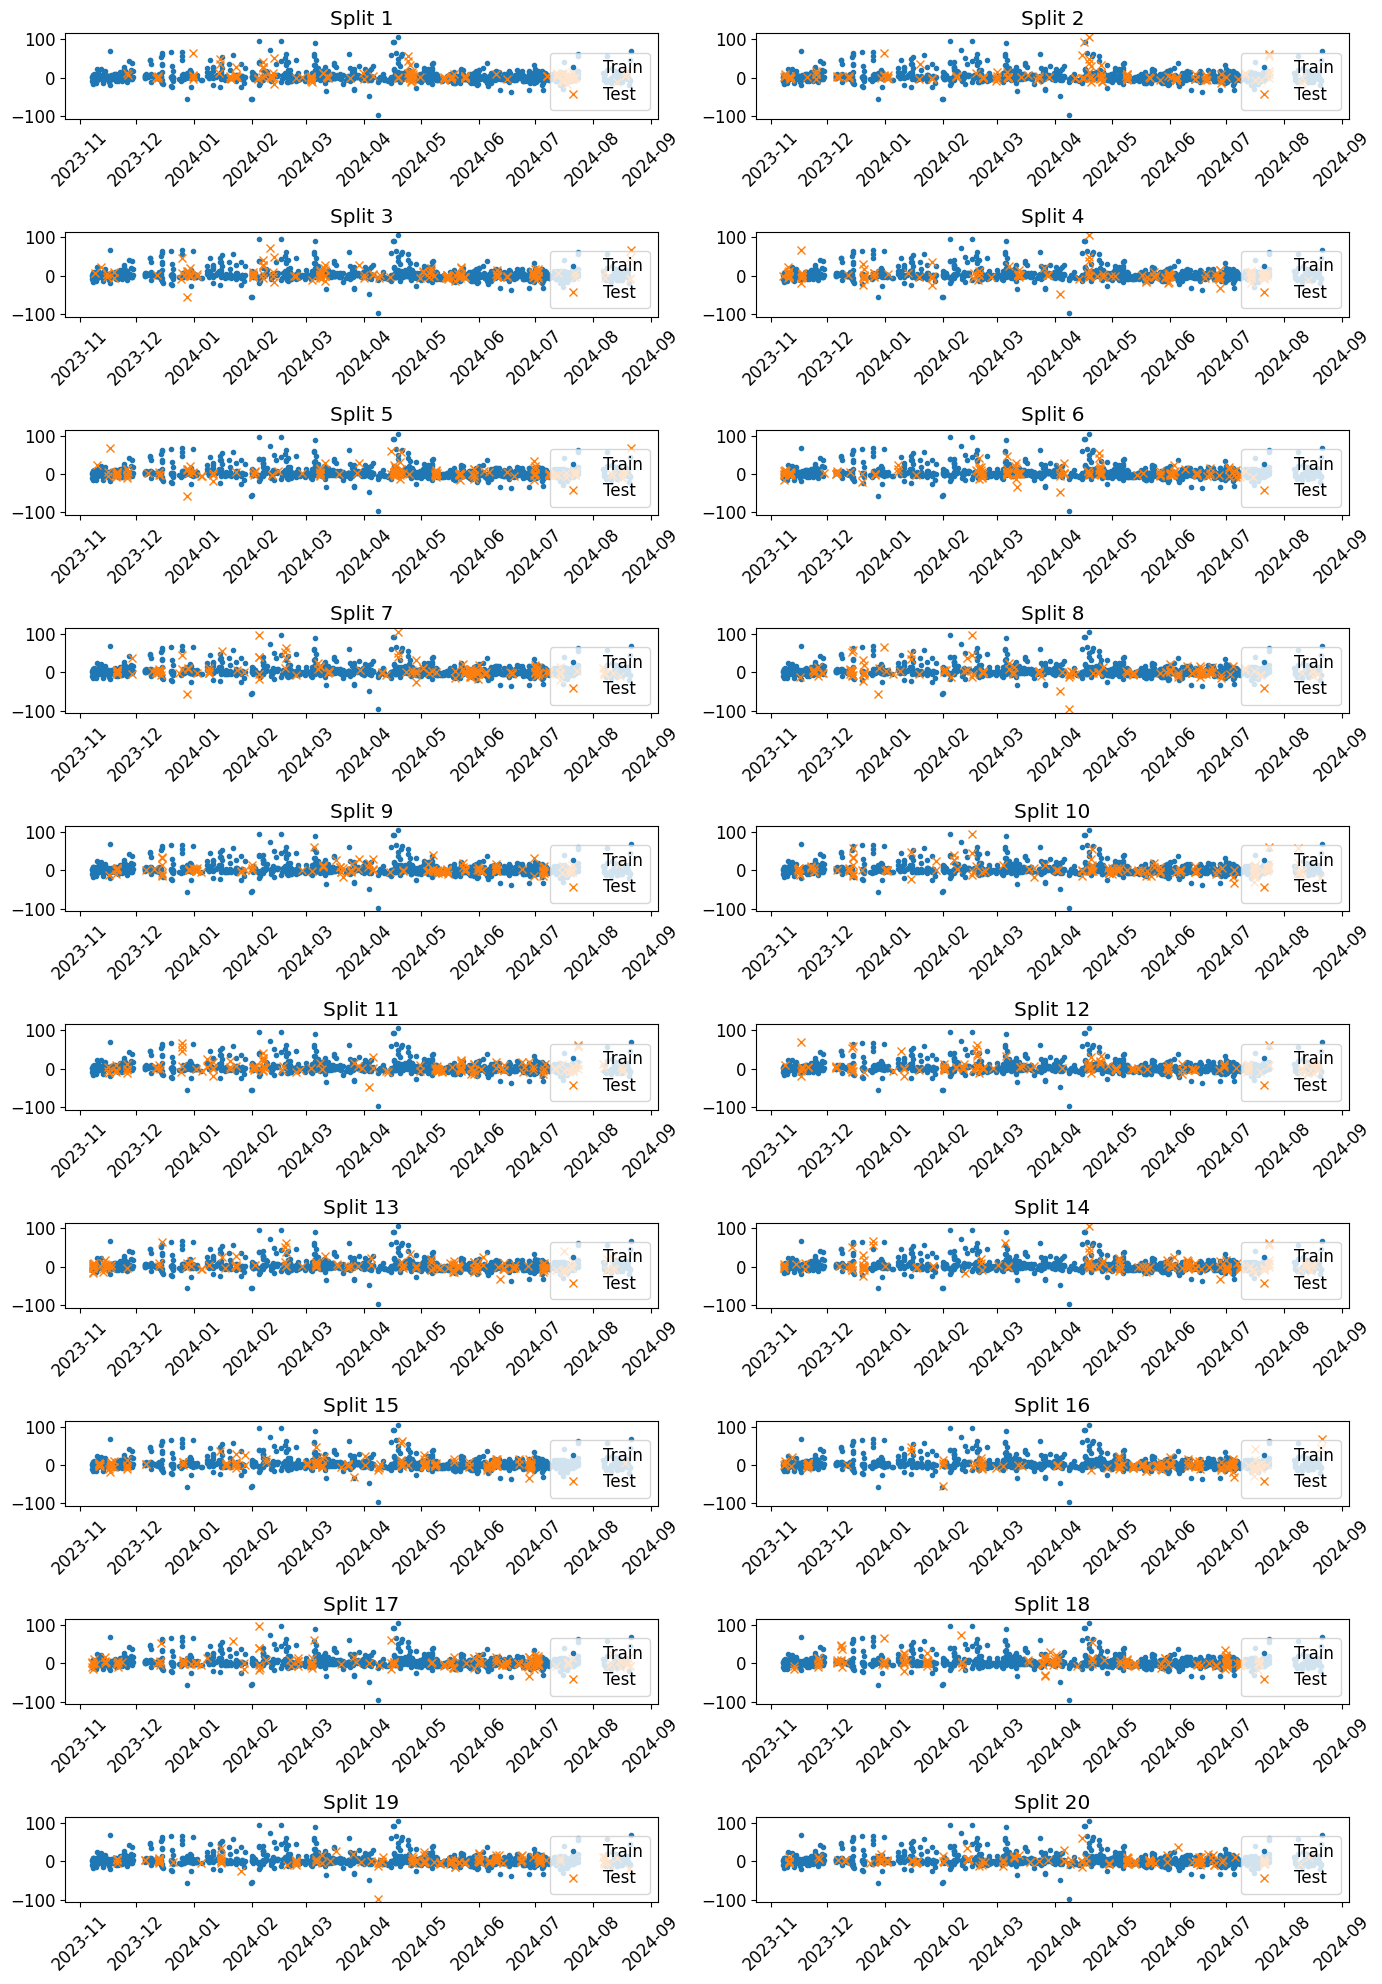

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FCH4_L3.3_CUT_84_QCF0
  RMSE:   13.9215
  MAE:    8.5789
  R2:     0.0549
----------------------------------------
Fitting final model on full training set...


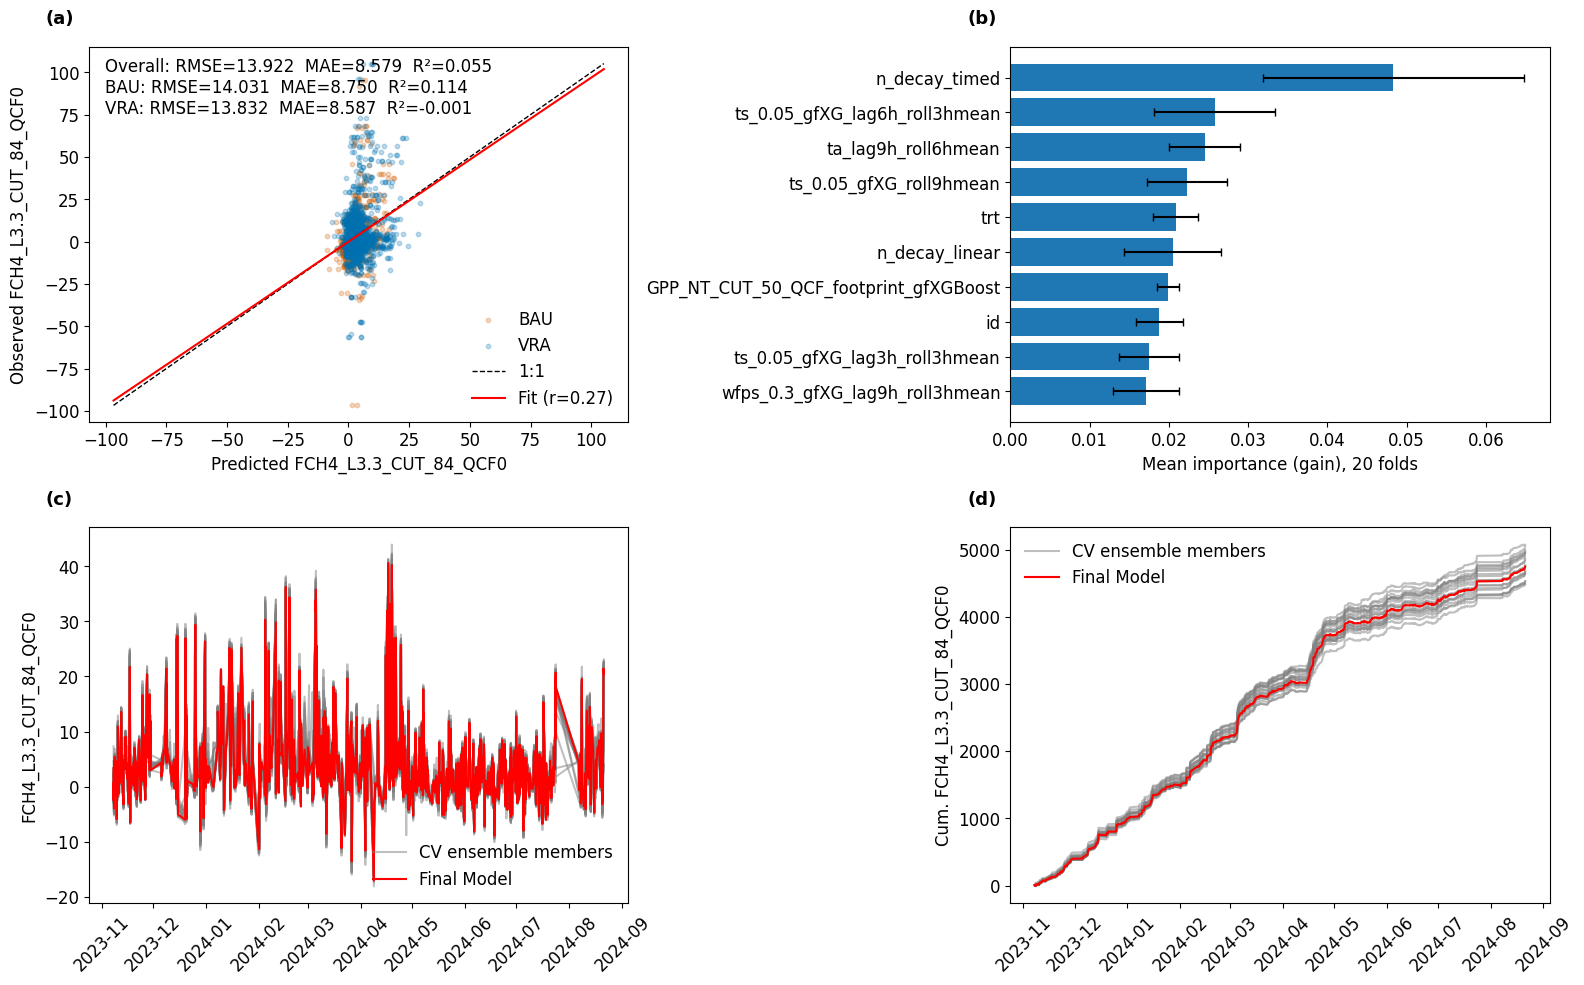

Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

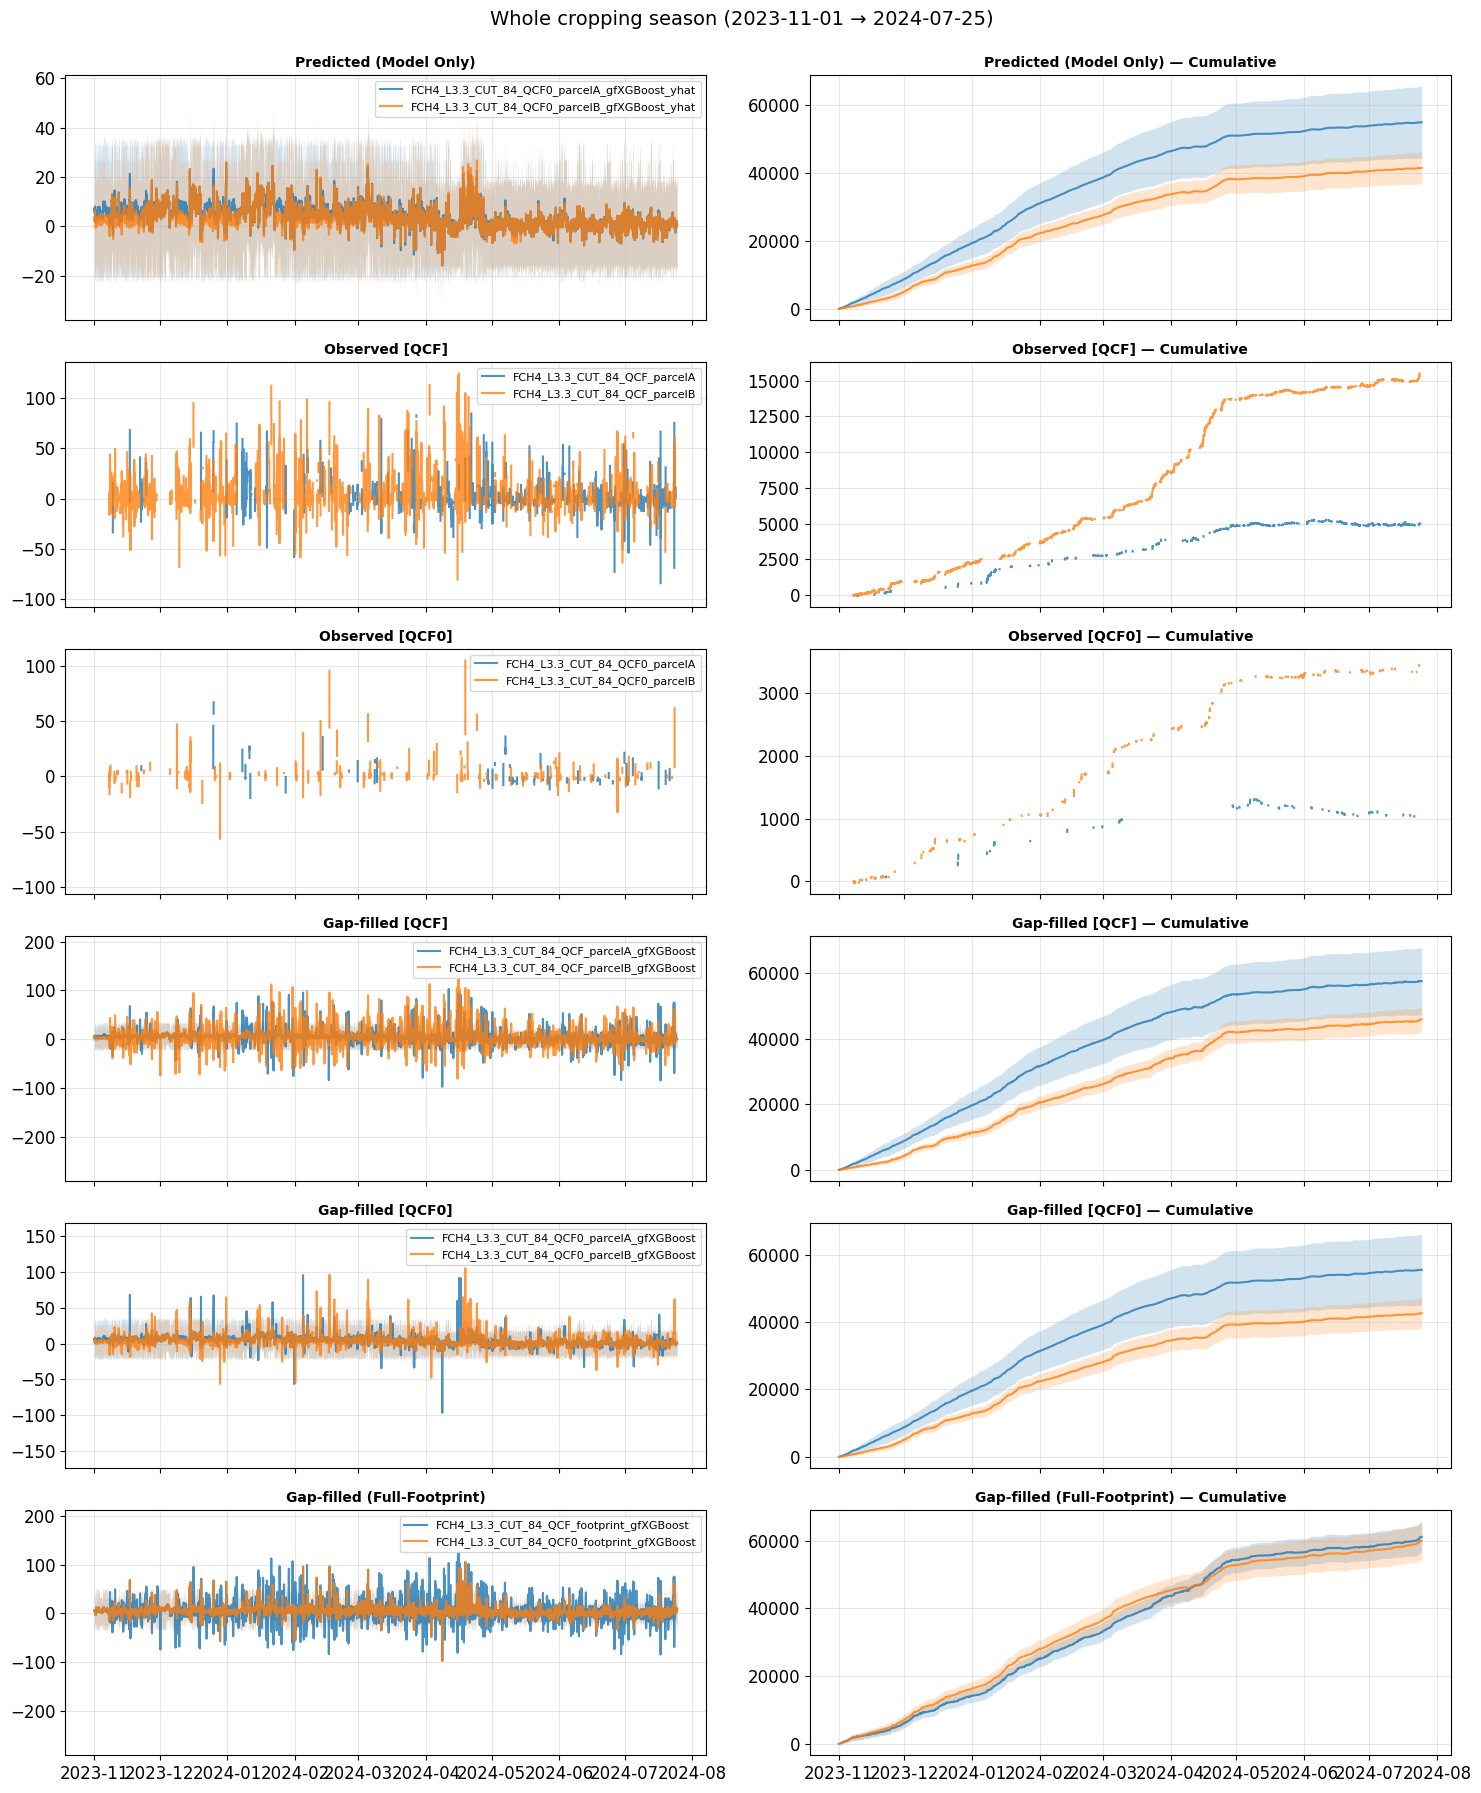

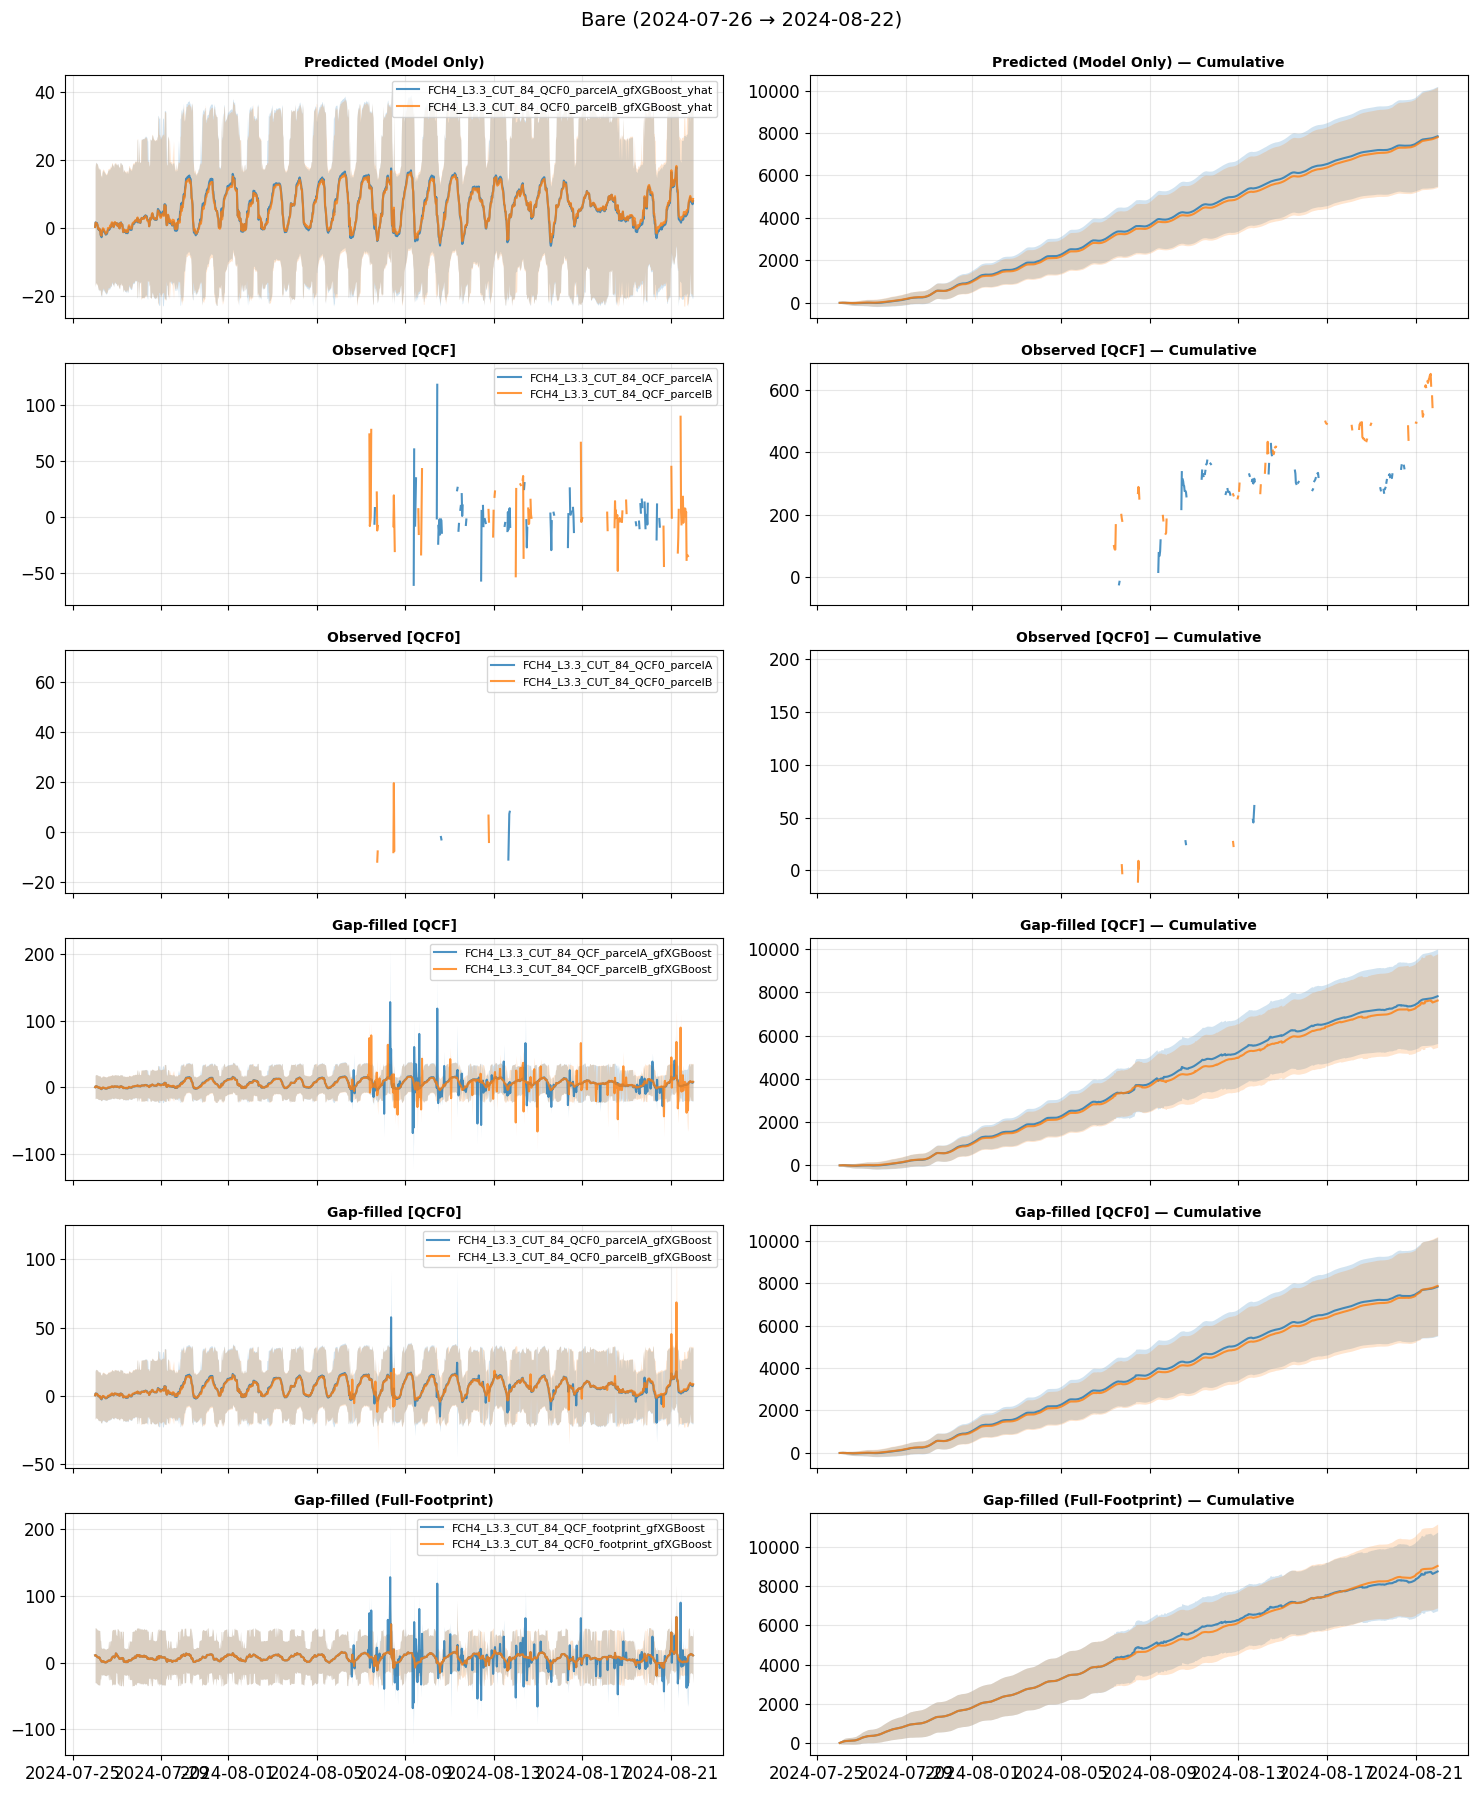

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-01", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()

# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_16_QCF_parcelA',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_16

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_50_QCF_parcelA',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_50

NEW VARIABLES FROM GAP-FILLING FCH4_L3.3_CUT_84_QCF0:


['FCH4_L3.3_CUT_84_QCF_parcelA',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'FCH4_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'FCH4_L3.3_CUT_84

,FCH4_L3.3_CUT_16_QCF_parcelA,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,FCH4_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,FCH4_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,15.261460,15.261460,1,13.338485,13.075809,2.634085,13.338485,NaN,17.512640,17.454775,10.550835,15.074436,9.065722,13.281243,...,9.226377,12.009424,12.355810,6.801429,10.232499,6.129135,10.217028,9.116857,10.450717,11.361929,12.222187,8.414920,10.017950,9.562045,6.800914
2023-10-17 00:45:00,NaN,15.261460,15.261460,1,13.336470,13.075809,2.623862,13.336470,NaN,17.512640,17.454775,10.550835,15.074436,9.065722,13.281243,...,9.226377,12.009424,12.355810,6.801429,10.232499,6.129135,10.217028,9.116857,10.450717,11.361929,12.222187,8.414920,10.017950,9.562045,6.800914
2023-10-17 01:15:00,NaN,15.261460,15.261460,1,13.336090,13.075809,2.621929,13.336090,NaN,17.512640,17.449797,10.543179,14.967556,9.065722,13.160710,...,9.226377,11.812408,12.355810,6.801429,10.232499,6.129135,10.217028,9.116857,10.450717,11.361929,12.215790,8.414920,10.017950,9.538696,6.777481
2023-10-17 01:45:00,NaN,15.349006,15.349006,1,13.337719,13.075809,2.630205,13.337719,NaN,17.512640,17.449797,10.494047,15.057104,9.065722,13.160710,...,9.226377,11.812408,12.355810,6.801429,10.232499,6.129135,10.217028,9.116857,10.450717,11.361929,12.215790,8.414920,10.017950,9.538696,6.777481
2023-10-17 02:15:00,NaN,15.349006,15.349006,1,13.336679,13.075809,2.624926,13.336679,NaN,17.512640,17.313152,10.494047,15.098944,9.065722,13.160710,...,9.226377,11.812408,12.355810,6.801429,10.232499,6.129135,10.217028,9.116857,10.453830,11.361929,12.161604,8.414920,10.017950,9.538696,6.769880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,9.294907,9.294907,1,18.313680,18.271600,1.240774,18.313680,NaN,8.937376,9.731897,8.063960,9.711077,6.734861,9.112673,...,9.595357,18.021265,9.114587,9.989895,10.564192,7.573919,8.432560,11.553395,10.851052,10.343584,7.505905,16.978292,8.561949,12.815619,11.402368
2024-08-22 22:15:00,NaN,9.550083,9.550083,1,13.143345,13.075809,1.330694,13.143345,NaN,8.814111,9.842412,8.352358,9.490985,6.408459,9.272712,...,10.477403,19.850744,9.726130,12.625524,11.330468,7.107531,8.893216,11.818524,10.705230,10.570889,7.306596,18.213465,9.309108,14.214412,12.261400
2024-08-22 22:45:00,NaN,9.404044,9.404044,1,13.144315,13.075809,1.340240,13.144315,NaN,8.320491,9.136513,7.560439,9.404510,6.710837,8.718871,...,10.951254,19.842901,10.883540,12.281166,11.088342,6.499568,8.532642,12.946166,10.205661,12.272376,7.199610,17.931871,10.492445,14.092903,14.336857


Cumulative plots to check differences between CUT16, CUT50 and CUT84

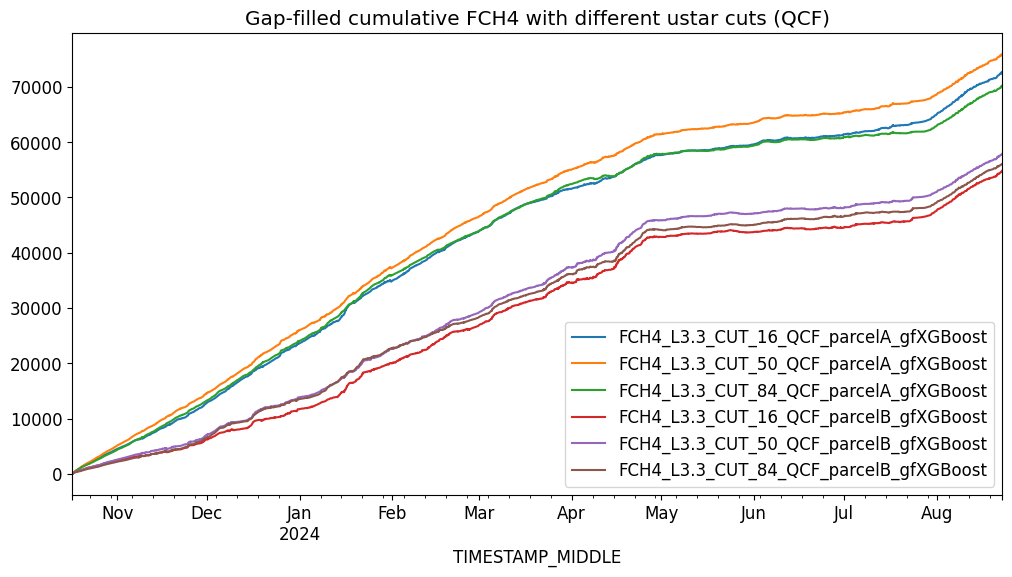

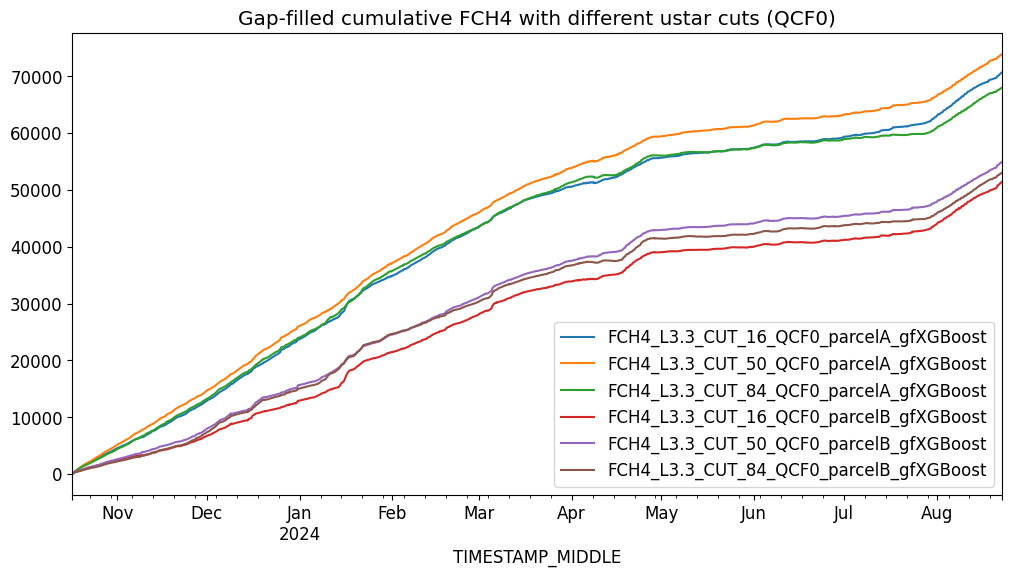

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelA_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelB_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelB_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelB_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"83.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 83.4.1_FCH4_GF-XGBoost.parquet (3.107 seconds).


'83.4.1_FCH4_GF-XGBoost.parquet'

# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-24 10:09:41
